In [2]:
%run Packages_and_Functions.ipynb

import seaborn as sns
# import matplotlib.pyplot as plt


In [3]:
def csv_to_array(path):
    df = pd.read_csv(path,index_col=0)  
    return df.to_numpy()

In [4]:
direct = "plots_paper/"
results_direct = "res_finalle/"

In [5]:
filetype = ".svg"
which_dist = ""

### Plotting Functions

In [11]:

def plot_soln_over_rel(res,p = lambda x: .3,which_algs = ALL_GENERAL_GRAPHS,N=Nrange,
                       title = "",rel = lambda x,y: 1,
                      xlabel="", ylabel="", save=False,DOMR = False):
    """p is a function of n, default to be constant .3
    rel is the denomenator in the range of the function """
    denom = np.array([rel(n,p) for n in N])
    fig, ax = plt.subplots()
    for i in which_algs:
        if i in ALL_COMPLETE:
            if (i == 1 or i ==2 or i==3 or i==4) and p(10) == 2/10:
                ax.plot(N,(res[i] + res[0])/denom,label=algo_dict[i],color=algo_color_dict[i], linestyle='dotted')
            else:
                ax.plot(N,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i], linestyle='dotted')
        else:
            if (i == 1 or i ==2 or i==3 or i==4) and p(10) == 2/10:
                ax.plot(N,(res[i] + res[0])/denom,label=algo_dict[i],color=algo_color_dict[i])
            else:
                ax.plot(N,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i])
    if DOMR:
        ax.plot(N,res[0]/denom,label=algo_dict[0],color=algo_color_dict[0])
    ax.grid(axis='y',alpha=.5)
    ax.set_xlabel(xlabel)
#     ax.yaxis.label.set(rotation='horizontal', ha='right');
    lims = ax.get_ylim()
    ax.yaxis.set_label_coords(-0.1,lims[1]/2)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.title.set_text(title)
    if save:
        fig.savefig(direct + save) 
    else:
        fig.show()
        
def plot_num_edges_removed(res,N = Nrange, which_algs = ALL_GENERAL_GRAPHS,relative = False,
                           title = "", xlabel="", ylabel="", save=False):
    fig, ax = plt.subplots()
    if not relative:
        for i in which_algs & ALL_ALGS_WITH_REMOVAL:
#             if i > 3:
#                 break
            if i in ALL_COMPLETE:
                ax.plot(N, (res[i+1]-res[i]),label=algo_dict[i],color=algo_color_dict[i], linestyle='dotted')
            else:
                ax.plot(N, (res[i+1]-res[i]),label=algo_dict[i],color=algo_color_dict[i],)
    else:
        for i in which_algs& ALL_ALGS_WITH_REMOVAL:
#             if i > 3:
#                 break
            if i in ALL_COMPLETE:
                ax.plot(N, (res[reduction_dict[i]]-res[i])/res[reduction_dict[i]],label=algo_dict[i],
                        color=algo_color_dict[i],linestyle='dotted')
            else:
                ax.plot(N, (res[reduction_dict[i]]-res[i])/res[reduction_dict[i]],label=algo_dict[i],
                        color=algo_color_dict[i])
    ax.grid(axis='y',alpha=.5)
#     ax.yaxis.label.set(rotation='horizontal', ha='right');
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    lims = ax.get_ylim()
    ax.yaxis.set_label_coords(-0.15,lims[1]/2)
    ax.set_ylabel(ylabel)



    ax.legend()
    ax.title.set_text(title)
    if save:
        fig.savefig(direct + save) 
    else:
        fig.show()

def algs_as_fn_p(res,P = Prange, which_algs = ALL_GENERAL_GRAPHS,rel = lambda x,y: 1,DOMR=False,
                           title = "", xlabel="", ylabel="", save=False):
    fig, ax = plt.subplots()
    denom = np.array([rel(70,lambda x:p) for p in P])
    for i in which_algs:
        if i in ALL_COMPLETE:
            ax.plot(P,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i],linestyle='dotted')
        else:
            ax.plot(P,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i])
    if DOMR:
        ax.plot(P,res[0]/denom,label=algo_dict[0],color=algo_color_dict[0])

    ax.grid(axis='y',alpha=.5)

    lims = ax.get_ylim()
    ax.yaxis.set_label_coords(-0.1,lims[1]/2)
    ax.set_ylabel(ylabel)

    ax.set_xlabel(xlabel)
    ax.legend()
    ax.title.set_text(title)
    if save:
        fig.savefig(direct + save) 
    else:
        fig.show()

NameError: name 'Prange' is not defined

# ----------------------------------

# ----------------------------------

# ----------------------------------

# ----------------------------------

# ----------------------------------

# ----------------------------------

# Final Plots Functions

In [12]:
direct = "plots_paper/" #where we output the plots to
results_direct = "res_finalle/" #where we get the results from

## Threshold things

In [9]:
# Plot threshold for Gamma
#Load Everything
# threshold_prob = csv_to_array(results_direct+"unifdem_threshold_prob.csv")
# threshold_prob_err = csv_to_array(results_direct + "unif_dem_threshold_prob_std.csv")

ps = len(threshold_prob[0])
powers = [2 - (1.9/ps)*i for i in range(ps)]


fig, ax = plt.subplots()
ax.plot(powers,threshold_prob[0],label = "Broken Cycle)")
ax.fill_between(powers,threshold_prob[0]+threshold_prob_err[0],threshold_prob[0]-threshold_prob_err[0],alpha=.3)
ax.fill_between(powers,threshold_prob[1]+threshold_prob_err[1],threshold_prob[1]-threshold_prob_err[1],alpha=.3)
ax.plot(powers,threshold_prob[1], label = "Any cycle")
ax.vlines([3/5,1],0,1,color='0',linestyles='dotted',alpha=.5)
# ax.set_ylabel('Probability of Appearance', ha='left', y=1, rotation=0, labelpad=0)

ax.yaxis.label.set(text = "Probability of Appearance ")
ax.yaxis.set_label_coords(-0.1,.5)


ax.xaxis.label.set(text = "$p=p(n)$")
ax.title.set_family('serif')
ax.grid(axis='y',alpha=.5)
ax.legend()
ax.set_ylim([-.1,1.1])
ax.set_xticks([.5,3/5,1,1.5], labels=["$\\frac{1}{\\sqrt{n}}$","$\\frac{1}{n^{3/5}}$","$\\frac{1}{n}$","$\\frac{1}{n^{1.5}}$"])

fig.savefig(direct + "threshold_probability.svg")
fig.show()



NameError: name 'threshold_prob' is not defined

## Algorithms performance

In [8]:

# funcions for p
const02 = lambda x: .3
const08 = lambda x: .8
over_sqrt = lambda x : 1/np.sqrt(x)
over_n = lambda x : 2/x

#Expected largest size of broken cycle:
# max_geoms{0:}

# function for "relative to what we measure success"
expected_num_edges = lambda x,p : (x * (x-1)/2)*p(x) #Computes the expected number of edges
expected_size_of_largest_cycle = lambda x,p : 0.5 - 2*np.log(x)/np.log(p(x)) 
## Names for headers
experiment_dict = {0: "$p=0.3$",
                  1: "$p=0.8$",
                  2: "$p=1/\sqrt{n}$",
                  3: "$p=2/n$"}

relative_dict = {0: "$\\frac{|sol|}{\mathbf{E}(|E|)}$",
                1: "|sol|",
#                 }
                2: "|sol|/max len of broken cycle"}

algo_dict = {0 : 'DOMR',
            1 : '$PIVOT$',
            2 : '$PIVOT(K_G)$',
            3: '$LHS$',
            4: '$LHS(K_G)$',
            5: '$SPC_{GMR}$',
            6: '$SPC_{GMR}(K_G)$',
            7: '$SPC_{IOMR}$',
            8: '$SPC_{IOMR}(K_G)$',
            9: 'SPC(GMR) Reduced',
            10: 'SPC(IOMR) Reduced '}


colors = sns.color_palette()

algo_color_dict = {0: colors[4],
                  1: colors[0],
                  2: colors[0],
                  3: colors[0],
                  4: colors[0],
                  5: colors[1],
                  6: colors[1],
                  7: colors[1],
                  8: colors[1],
                  9: colors[2],
                  10: colors[3]}


## Load all files
algs_08 = csv_to_array(results_direct+which_dist+"alg_p08.csv")
algs_02 = csv_to_array(results_direct+which_dist+"alg_p03.csv")
algs_n = csv_to_array(results_direct+which_dist+"alg_p1overn.csv")
algs_sqrt = csv_to_array(results_direct+which_dist+"alg_p_sqrt(n).csv")

# Load Preformance as function of $p$
# pref_as_fn_p = csv_to_array(results_direct+"algos_as_fn_p.csv")
# ps=100
# start = 1-0.1
# end = 0.1
# delta = (start-end)/ps
# Prange = [end + delta*i for i in range(ps)]

## Lists of all things needed
ALL_P = [const02, const08, over_sqrt, over_n]
ALL_RES = [algs_02, algs_08, algs_sqrt, algs_n]
# ALL_RES = [algs_03, algs_07, algs_sqrt, algs_n]
ALL_RELATIVE = [expected_num_edges, lambda x,y : 1,expected_size_of_largest_cycle]

ALL_ALGS_WITH_REMOVAL = set([1,3,9,10])


ALL_GENERAL_GRAPHS=set([0,1,3,5,7,9,10]) ## All results for general graphs
ALL_IOMR = set([3,4,7,8,10]) ## All IOMR algiorithms
ALL_MR = set([1,2,5,6,9]) ## All GMR algorithms
ALL_COMPLETE = set([0,2,4,6,8]) ## All results for complete graphs

ALL_BEFORE_11_ALGS = set(range(9)) ## To intersect for results before round 3

## Dictionary to send index of algorithm after reduction to its counterpart  - 
## that is, before reduction but after completion, like Pivot(complete) to Pivot

reduction_dict={1:2, #Pivot
               3:4,
               9:6,
               10:7} #L+1 appxn
Nrange = range(50,50+len(algs_08[0]))



## GMR plots

### Sol as fn of n

In [10]:
savedictabs= {0:"fn_of_n_abs_03",
          1:"fn_of_n_abs_08",
          2:"fn_of_n_abs_sqrt",
          3:"fn_of_n_abs_overn"}

savedictrel= {0:"fn_of_n_relative_03",
          1:"fn_of_n_relative_08",
          2:"fn_of_n_relative_sqrt",
          3:"fn_of_n_relative_overn"}

for i in range(4):
#     if i == 0:
#         continue
    p = ALL_P[i]
    res = ALL_RES[i]
#         title = relative_dict[j] + "as fn of $n$: " + experiment_dict[i]
    savename = "GMR/" +which_dist+ savedictabs[i] +filetype
#         savename=False
    plot_soln_over_rel(res,p,rel = ALL_RELATIVE[1], which_algs = (ALL_MR&ALL_BEFORE_11_ALGS),
                       N=Nrange,
#                            title=experiment_dict[i],
                           xlabel="$n$",
                         ylabel='$|ALG|$',
                           save=savename,
                      DOMR = 1)


    savename = "GMR/" +which_dist+ savedictrel[i] +filetype
#         savename=False
    plot_soln_over_rel(res,p,rel = ALL_RELATIVE[0], which_algs =  ALL_GENERAL_GRAPHS&ALL_MR&ALL_BEFORE_11_ALGS,
                       N=Nrange,
#                            title=experiment_dict[i],
                           xlabel="$n$",
                      ylabel="$|ALG|/ \\mathbb{E}(|E|)$",
                           save=savename,
                      DOMR = 1)

    plot_soln_over_rel(res,p,rel = ALL_RELATIVE[2], which_algs =  ALL_GENERAL_GRAPHS&ALL_MR&ALL_BEFORE_11_ALGS,
                       N=Nrange,
#                            title=experiment_dict[i],
                           xlabel="$n$",
                      ylabel="$|ALG|/ \mathbb{E}(max-geom)$",
                           save=savename,
                      DOMR = 1)    
savedict_discarded_abs = {0 :"discarded_03",
                            1:"discarded_08",
                            2:"discarded_sqrt",
                            3: "discarded_overn"
                         }
savedict_discarded_rel = {0:"relative_discarded_03",
                            1:"relative_discarded_08",
                            2:"relative_discarded_sqrt",
                            3:"relative_discarded_overn"
                         }
# for i in range(4):
# #     if i ==0:
# #         continue
#     p = ALL_P[i]
#     res = ALL_RES[i]
#     savename = "GMR/"+which_dist+savedict_discarded_rel[i]+filetype
# #     savename=False
#     plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_MR&ALL_BEFORE_11_ALGS, relative=True,
#                            N=Nrange,
# #                            title = experiment_dict[i],
#                            xlabel="$n$",
#                            ylabel="Fraction of discarded edges",
#                             save = savename)
    
#     savename = "GMR/"+which_dist+savedict_discarded_abs[i]+filetype
# #     savename=False
#     plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_MR&ALL_BEFORE_11_ALGS, relative=False,
#                            N=Nrange,
# #                            title = experiment_dict[i],
#                            xlabel="$n$",
#                            ylabel="Number of discarded edges",
#                             save = savename)


NameError: name 'plot_soln_over_rel' is not defined

### Sol as fn of p

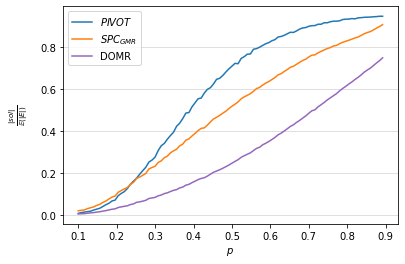

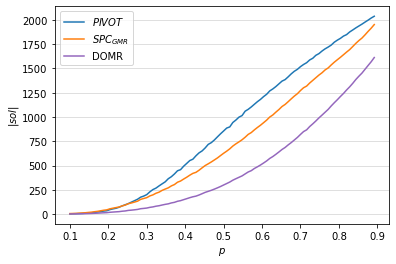

In [26]:
savename = "GMR/" +which_dist+ "fn_of_p_relative" + filetype
# savename=False
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_MR& ALL_BEFORE_11_ALGS,
            title="",
            DOMR=1,
             rel = ALL_RELATIVE[0],
            xlabel="$p$",
            ylabel="$\\frac{|sol|}{\mathbb{E}(|E|)}$",
            save=savename)

savename = "GMR/"+which_dist+"fn_of_p_abs" + filetype
# savename=False
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_MR& ALL_BEFORE_11_ALGS,
            title="",
            DOMR=1,
            xlabel="$p$",
            ylabel="$|sol|$",
             save=savename,
            )

## IOMR plots

### Sol as fn of n

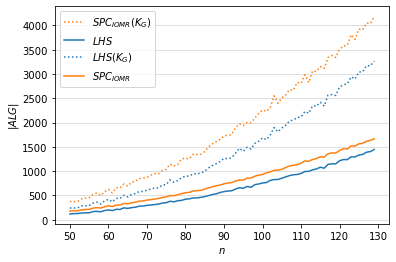

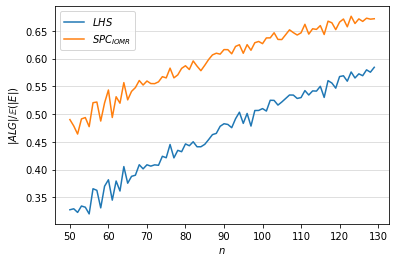

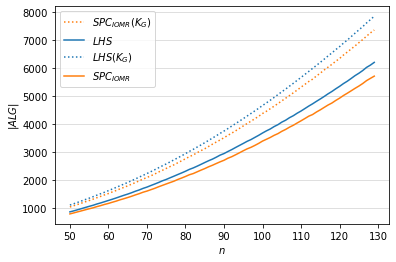

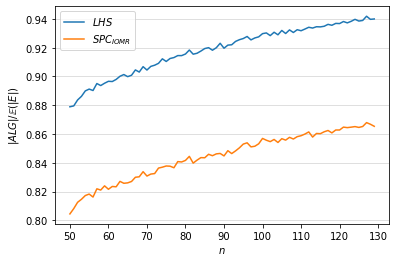

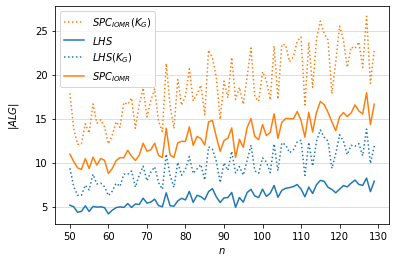

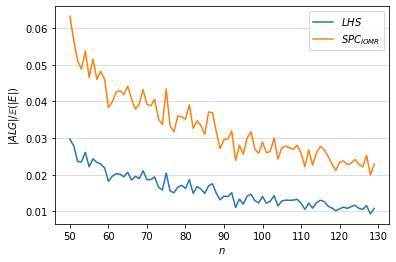

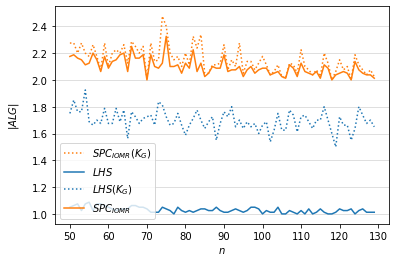

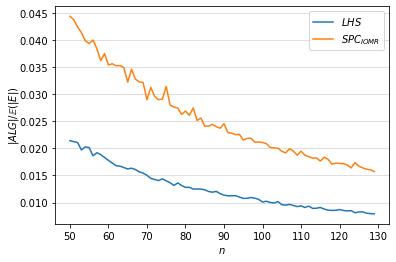

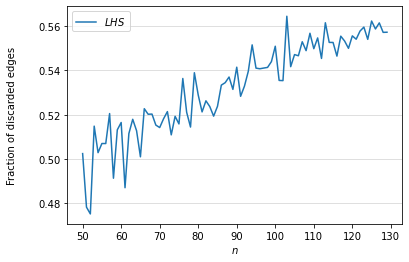

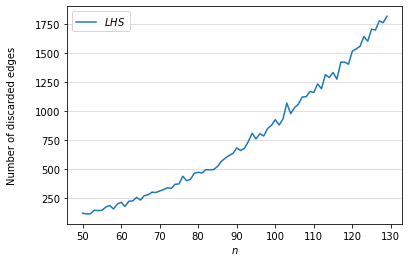

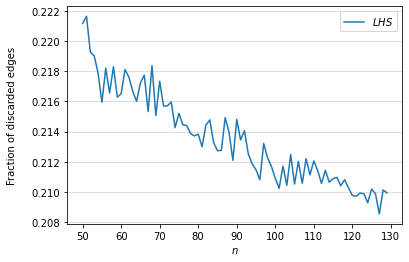

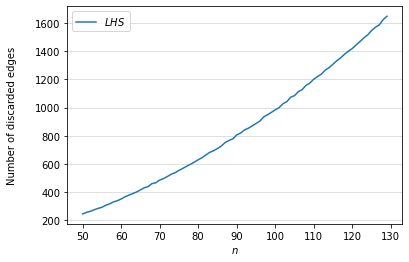

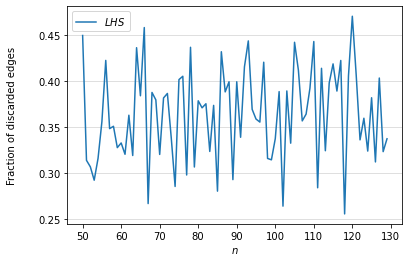

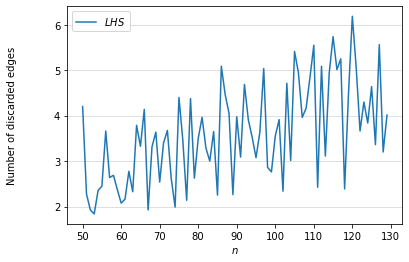

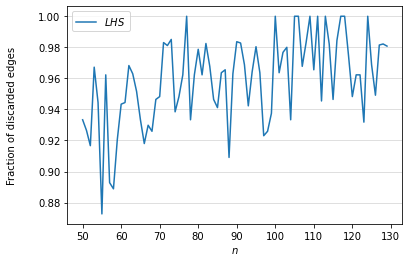

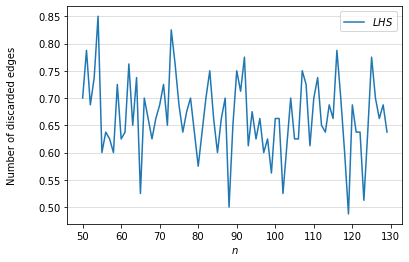

In [372]:
savedictabs= {0:"fn_of_n_abs_03",
          1:"fn_of_n_abs_08",
          2:"fn_of_n_abs_sqrt",
          3:"fn_of_n_abs_overn"}

savedictrel= {0:"fn_of_n_relative_03",
          1:"fn_of_n_relative_08",
          2:"fn_of_n_relative_sqrt",
          3:"fn_of_n_relative_overn"}

for i in range(4):
# 
    p = ALL_P[i]
    res = ALL_RES[i]
#         title = relative_dict[j] + "as fn of $n$: " + experiment_dict[i]
    savename = "IOMR/" +which_dist+ savedictabs[i] +filetype
#         savename=False
    plot_soln_over_rel(res,p,rel = ALL_RELATIVE[1], which_algs = (ALL_IOMR&ALL_BEFORE_11_ALGS),
                       N=Nrange,
#                            title=experiment_dict[i],
                           xlabel="$n$",
                         ylabel="$|ALG|$",
                           save=savename)


    savename = "IOMR/" +which_dist+ savedictrel[i] +filetype
#         savename=False
    plot_soln_over_rel(res,p,rel = ALL_RELATIVE[0], which_algs =  ALL_GENERAL_GRAPHS&ALL_IOMR&ALL_BEFORE_11_ALGS,
                       N=Nrange,
#                            title=experiment_dict[i],
                           xlabel="$n$",
                          ylabel="$|ALG|/ \\mathbb{E}(|E|)$",

                           save=savename)

savedict_discarded_abs = {0 :"discarded_03",
                            1:"discarded_08",
                            2:"discarded_sqrt",
                            3: "discarded_overn"
                         }
savedict_discarded_rel = {0:"relative_discarded_03",
                            1:"relative_discarded_08",
                            2:"relative_discarded_sqrt",
                            3:"relative_discarded_overn"
                         }
for i in range(4):
    p = ALL_P[i]
    res = ALL_RES[i]
    savename = "IOMR/"+which_dist+savedict_discarded_rel[i]+filetype
#     savename=False
    plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_IOMR&ALL_BEFORE_11_ALGS, relative=True,
                           N=Nrange,
#                            title = experiment_dict[i],
                           xlabel="$n$",
                          ylabel="Fraction of discarded edges",
                            save = savename)
    
    savename = "IOMR/"+which_dist+savedict_discarded_abs[i]+filetype
#     savename=False
    plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_IOMR&ALL_BEFORE_11_ALGS, relative=False,
                           N=Nrange,
#                            title = experiment_dict[i],
                          ylabel="Number of discarded edges",
                           xlabel="$n$",
                            save = savename)


### Sol as fn of p

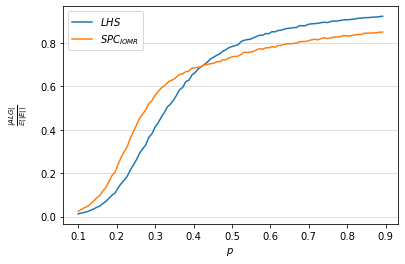

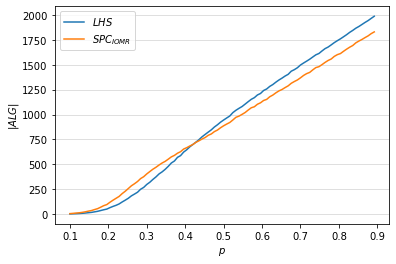

In [371]:
savename = "IOMR/"+which_dist+"fn_of_p_relative" + filetype
# savename=False
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_IOMR& ALL_BEFORE_11_ALGS,
            title="",
            DOMR=0,
             rel = ALL_RELATIVE[0],
            xlabel="$p$",
            ylabel="$ \\frac{|ALG|}{\mathbb{E}(|E|)}$",
            save=savename)

savename = "IOMR/"+which_dist+"fn_of_p_abs" + filetype
# savename=False
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_IOMR& ALL_BEFORE_11_ALGS,
            title="",
            DOMR=0,
            xlabel="$p$",
            ylabel="$|ALG|$",
             save=savename)